In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Lasso, Ridge   # 线性回归模型
from sklearn.preprocessing import PolynomialFeatures  # 构建多项式特征
from sklearn.model_selection import train_test_split  # 划分训练集和测试集
from sklearn.metrics import mean_squared_error  # 均方误差损失函数

# 设置字体
plt.rcParams['font.sans-serif'] = ['KaiTi']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 生成数据，-3 到 3 生成 300 个点
X = np.linspace(-3, 3, 300).reshape(-1, 1)
# 300个点的，生成-0.5 到0.5 之间的随机数，然后重新塑形，将它变成一行一列
y = np.sin(X) + np.random.uniform(-0.5, 0.5, 300).reshape(-1, 1)
print(X.shape, y.shape)
# 划分训练集和测试集。默认会随机打乱顺序。random_state 是随机种子。如果不固定，每次随机都不一样。
trainX, testX, trainY, testY = train_test_split(X, y, test_size=0.2, random_state=42)



(300, 1) (300, 1)


(1, 21)


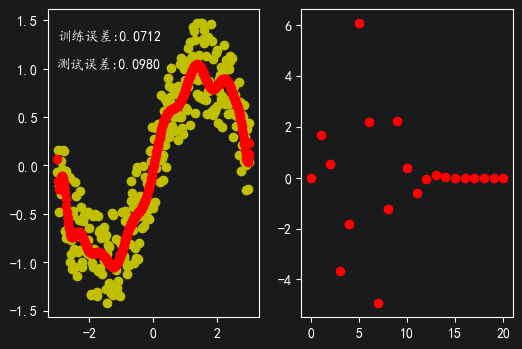

In [15]:

# 一、不加正则化项
#过拟合的情况
# 通过PolynomialFeatures 将X 分解为20个特征。 特征1就是x的20次方，特征2就是x的19次方
poly20 = PolynomialFeatures(degree=20)
X_train_poly3 = poly20.fit_transform(trainX)
X_test_poly3 = poly20.fit_transform(testX)

#训练模型
model = LinearRegression()
model.fit(X_train_poly3, trainY)
# 预测结果计算误差
# 计算训练误差
train_mse3 = mean_squared_error(trainY, model.predict(X_train_poly3))
# 计算测试误差
test_mes3 = mean_squared_error(testY, model.predict(X_test_poly3))

# 画图出恰好拟合的那张图
fig, ax = plt.subplots(1, 2, figsize=(6, 4))
ax[0].scatter(X, y, c='y')
ax[0].scatter(X,model.predict(poly20.fit_transform(X)), c='r')
ax[0].text(-3,1,f"测试误差:{test_mes3:.4f}")
ax[0].text(-3,1.3,f"训练误差:{train_mse3:.4f}")
ax[1].scatter(np.arange(21),model.coef_[0,:], c='r')
print(model.coef_.shape)


(21,)


D:\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.196e+01, tolerance: 1.415e-02
  model = cd_fast.enet_coordinate_descent(


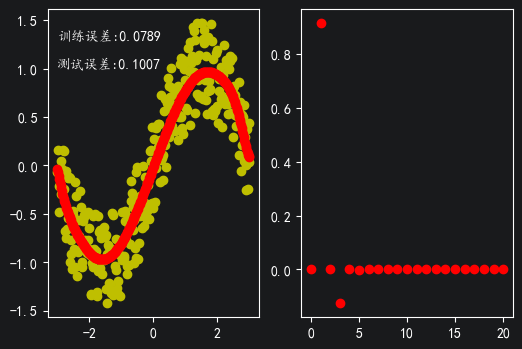

In [28]:
# 二、加L1正则化项（Lasso回归）
lasso = Lasso(alpha=0.01)
#训练模型
lasso.fit(X_train_poly3,trainY )
#计算误差
train_loss_L1 = mean_squared_error(trainY, lasso.predict(X_train_poly3))
test_loss_L1 = mean_squared_error(testY, lasso.predict(X_test_poly3))
#画图
fig, ax = plt.subplots(1, 2, figsize=(6, 4))
ax[0].scatter(X, y, c='y')
ax[0].scatter(X,lasso.predict(poly20.fit_transform(X)), c='r')
ax[0].text(-3,1,f"测试误差:{test_loss_L1:.4f}")
ax[0].text(-3,1.3,f"训练误差:{train_loss_L1:.4f}")
ax[1].scatter(np.arange(21),lasso.coef_.reshape(1,-1), c='r')
print(lasso.coef_.shape)


(1, 21)


D:\Python311\Lib\site-packages\sklearn\linear_model\_ridge.py:200: LinAlgWarning: Ill-conditioned matrix (rcond=1.14036e-20): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


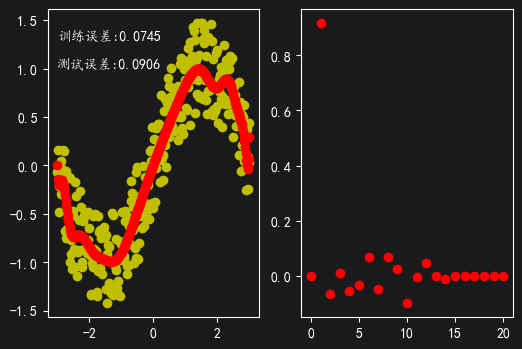

In [29]:
# 二、加L2正则化项（岭回归）
ridge = Ridge(alpha=1)
#训练模型
ridge.fit(X_train_poly3,trainY )
#计算误差
train_loss_L2 = mean_squared_error(trainY, ridge.predict(X_train_poly3))
test_loss_L2 = mean_squared_error(testY, ridge.predict(X_test_poly3))
#画图
fig, ax = plt.subplots(1, 2, figsize=(6, 4))
ax[0].scatter(X, y, c='y')
ax[0].scatter(X,ridge.predict(poly20.fit_transform(X)), c='r')
ax[0].text(-3,1,f"测试误差:{test_loss_L2:.4f}")
ax[0].text(-3,1.3,f"训练误差:{train_loss_L2:.4f}")
ax[1].scatter(np.arange(21),ridge.coef_.reshape(1,-1), c='r')
print(ridge.coef_.shape)
